Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Create Synthetic Software Engineering Dataset

In [2]:
np.random.seed(42)

data = {
    "LOC": np.random.randint(100, 10000, 100), # line of codes
    "Complexity": np.random.randint(1, 50, 100),
    "Developers": np.random.randint(1, 10, 100),
    "Bugs": np.random.randint(0, 100, 100),
    "Dev_Time": np.random.randint(5, 200, 100)
}

df = pd.DataFrame(data)
print("Dataset Preview:")
print(df.head())

Dataset Preview:
    LOC  Complexity  Developers  Bugs  Dev_Time
0  7370           7           2    50        62
1   960           9           6    53        90
2  5490           8           7     7        53
3  5291          12           5    26       184
4  5834          34           1    26       174


Feature Scaling (Important for Euclidean Distance)

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Function to Calculate WCSS

In [4]:
def calculate_wcss(data, k_range):
    wcss = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
        kmeans.fit(data)
        wcss.append(kmeans.inertia_)  # inertia_ = WCSS
    return wcss

Compute WCSS for k = 2 to 8

In [5]:
k_values = list(range(2, 9))
wcss_values = calculate_wcss(X_scaled, k_values)

# Display WCSS values
wcss_df = pd.DataFrame({
    "k": k_values,
    "WCSS": wcss_values
})
print("\nWCSS Values:")
print(wcss_df)


WCSS Values:
   k        WCSS
0  2  418.473093
1  3  360.778064
2  4  334.049168
3  5  279.029311
4  6  259.500247
5  7  246.363340
6  8  216.770019


Plot Elbow Method

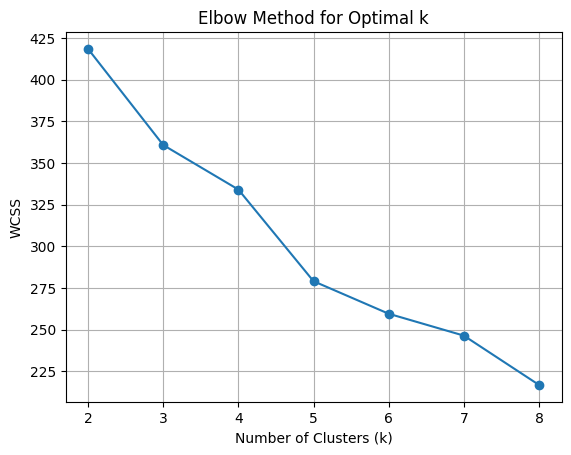

In [6]:
plt.figure()
plt.plot(k_values, wcss_values, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal k")
plt.grid()
plt.show()

Apply K-Means with Optimal k (example: k=3)

In [7]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to DataFrame
df['Cluster'] = clusters

print("\nClustered Data:")
print(df.head())



Clustered Data:
    LOC  Complexity  Developers  Bugs  Dev_Time  Cluster
0  7370           7           2    50        62        2
1   960           9           6    53        90        0
2  5490           8           7     7        53        0
3  5291          12           5    26       184        2
4  5834          34           1    26       174        2


Cluster Analysis using DataFrames

In [8]:
for i in range(optimal_k):
    print(f"\n--- Cluster {i} ---")
    print(df[df['Cluster'] == i])


--- Cluster 0 ---
     LOC  Complexity  Developers  Bugs  Dev_Time  Cluster
1    960           9           6    53        90        0
2   5490           8           7     7        53        0
13  2533          22           8    60       112        0
15  5151          35           6    18       107        0
16  6520           1           8     3        10        0
17  1284          35           5    34       113        0
20  6496          14           6    16        51        0
23  2658           5           9    29       172        0
25  2147          14           3    45       148        0
28   289           9           3    36       128        0
29  2834          15           3    23       110        0
32  1999          42           7    52       149        0
34  1367          32           9    98        67        0
39  5493          30           8    31        94        0
41  8533          23           9    32        66        0
44  7141          15           7    24       141     

Cluster Summary (Mean Values)

In [9]:
cluster_summary = df.groupby('Cluster').mean()
print("\nCluster Summary (Mean Values):")
print(cluster_summary)


Cluster Summary (Mean Values):
                 LOC  Complexity  Developers       Bugs    Dev_Time
Cluster                                                            
0        3607.205882   16.794118    6.470588  39.205882  101.823529
1        4890.722222   38.305556    4.222222  52.722222   55.861111
2        7403.733333   23.066667    3.600000  56.933333  143.500000


Visualizing Clusters (2D Projection)

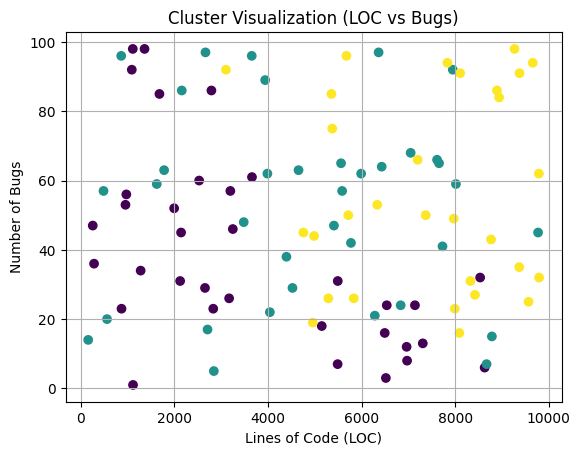

In [10]:
plt.figure()
plt.scatter(df['LOC'], df['Bugs'], c=df['Cluster'])
plt.xlabel("Lines of Code (LOC)")
plt.ylabel("Number of Bugs")
plt.title("Cluster Visualization (LOC vs Bugs)")
plt.grid()
plt.show()